Total real-world test images: 18

 EVALUATING: EfficientNetB0
Model loaded successfully.
Total Images Tested   : 18
Correct Predictions   : 12
Overall Accuracy      : 66.67%
Average Confidence    : 91.40%

Per-Class Accuracy:
          Class  Tested  Correct  Accuracy (%)
     Alternaria       2        0           0.0
    Anthracnose       5        5         100.0
Black Mould Rot       2        0           0.0
        Healthy       5        5         100.0
   Stem end Rot       4        2          50.0

Classification Report:
                 precision    recall  f1-score   support

     Alternaria       0.00      0.00      0.00         2
    Anthracnose       0.62      1.00      0.77         5
Black Mould Rot       0.00      0.00      0.00         2
        Healthy       1.00      1.00      1.00         5
   Stem end Rot       0.50      0.50      0.50         4

       accuracy                           0.67        18
      macro avg       0.42      0.50      0.45        18
   weighte

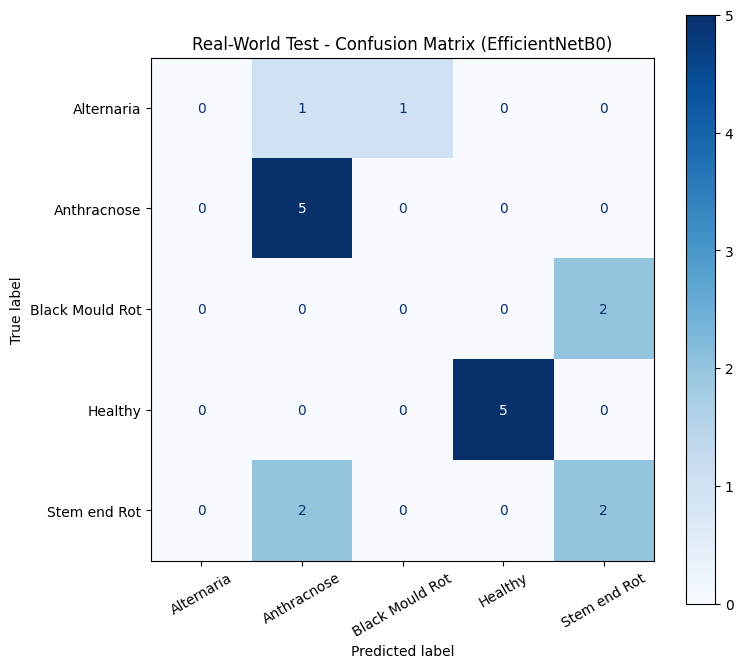



 EVALUATING: ResNet50
Model loaded successfully.
Total Images Tested   : 18
Correct Predictions   : 10
Overall Accuracy      : 55.56%
Average Confidence    : 96.65%

Per-Class Accuracy:
          Class  Tested  Correct  Accuracy (%)
     Alternaria       2        0           0.0
    Anthracnose       5        5         100.0
Black Mould Rot       2        0           0.0
        Healthy       5        4          80.0
   Stem end Rot       4        1          25.0

Classification Report:
                 precision    recall  f1-score   support

     Alternaria       0.00      0.00      0.00         2
    Anthracnose       0.42      1.00      0.59         5
Black Mould Rot       0.00      0.00      0.00         2
        Healthy       1.00      0.80      0.89         5
   Stem end Rot       0.50      0.25      0.33         4

       accuracy                           0.56        18
      macro avg       0.38      0.41      0.36        18
   weighted avg       0.50      0.56      0.48  

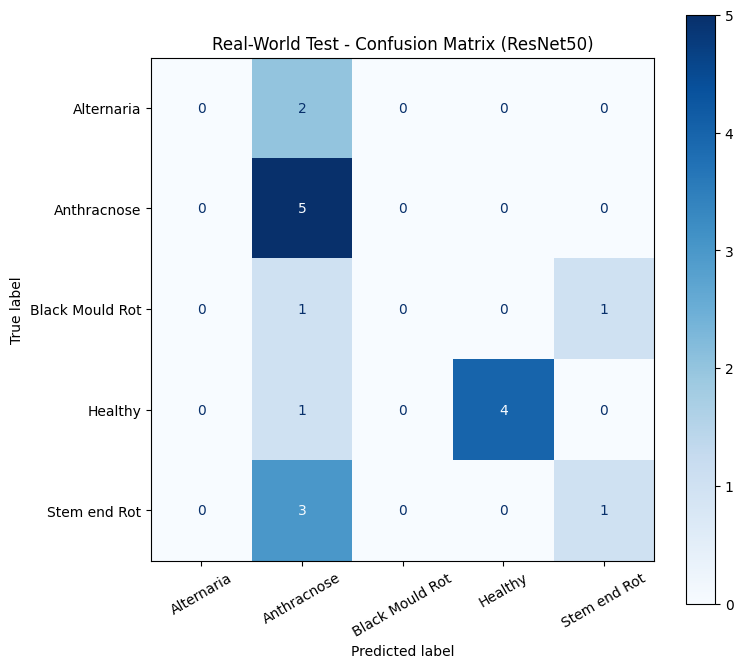

In [1]:
"""
MangoCare - Mango Fruit Disease Models: Real-World Google Image Test
=========================================================================
Loads BOTH saved models (EfficientNetB0 and ResNet50) and evaluates them
on the same folder of real-world (non-Kaggle) test images, producing
per-model reports plus a side-by-side comparison.

Preprocessing note: both training scripts bake `preprocess_input` INSIDE
the model graph (right after the Input layer), so this script feeds raw
0-255 pixel arrays to both models directly - no manual rescaling needed.

EXPECTED FOLDER STRUCTURE for GOOGLE_TEST_DIR (one subfolder per class,
matching the class names below):
    GOOGLE_TEST_DIR/
        Alternaria/
        Anthracnose/
        Black Mould Rot/
        Healthy/
        Stem end Rot/

pip install tensorflow pandas matplotlib seaborn scikit-learn --quiet
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# =========================================================
# CONFIG
# =========================================================
GOOGLE_TEST_DIR = r"D:\Fruit Disease detection\Google Image Dataset"   # <-- CHANGE THIS
IMG_SIZE = (224, 224)   # both models trained at this resolution

MODELS = {
    "EfficientNetB0": r"mango_fruit_efficientnetb0_final.keras",
    "ResNet50": r"mango_fruit_resnet50_final.keras",
}

class_names = [
    "Alternaria",
    "Anthracnose",
    "Black Mould Rot",
    "Healthy",
    "Stem end Rot",
]

OUT_DIR = "fruit_google_test_results"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================================================
# COLLECT TEST IMAGES ONCE (shared across both models)
# =========================================================
image_paths, true_labels = [], []
for cls in class_names:
    cls_folder = os.path.join(GOOGLE_TEST_DIR, cls)
    if not os.path.exists(cls_folder):
        print(f"WARNING: folder not found for class '{cls}': {cls_folder}")
        continue
    for fname in os.listdir(cls_folder):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(cls_folder, fname))
            true_labels.append(cls)

print(f"Total real-world test images: {len(image_paths)}")

# =========================================================
# EVALUATE EACH MODEL
# =========================================================
all_results = {}

for model_name, model_path in MODELS.items():
    print("\n" + "=" * 60)
    print(f" EVALUATING: {model_name}")
    print("=" * 60)

    if not os.path.exists(model_path):
        print(f"  Model file not found, skipping: {model_path}")
        continue

    model = tf.keras.models.load_model(model_path)
    print("Model loaded successfully.")

    predicted_labels, confidences = [], []
    for image_path in image_paths:
        img = load_img(image_path, target_size=IMG_SIZE)
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        prediction = model.predict(img_array, verbose=0)
        predicted_index = np.argmax(prediction)
        predicted_labels.append(class_names[predicted_index])
        confidences.append(np.max(prediction))

    df = pd.DataFrame({
        "Image": [os.path.basename(p) for p in image_paths],
        "Actual": true_labels,
        "Predicted": predicted_labels,
        "Confidence (%)": [c * 100 for c in confidences],
    })

    correct = (df["Actual"] == df["Predicted"]).sum()
    total = len(df)
    accuracy = correct / total * 100

    print(f"Total Images Tested   : {total}")
    print(f"Correct Predictions   : {correct}")
    print(f"Overall Accuracy      : {accuracy:.2f}%")
    print(f"Average Confidence    : {df['Confidence (%)'].mean():.2f}%")

    print("\nPer-Class Accuracy:")
    per_class = []
    for cls in class_names:
        cls_data = df[df["Actual"] == cls]
        if len(cls_data) == 0:
            continue
        cls_correct = (cls_data["Actual"] == cls_data["Predicted"]).sum()
        per_class.append({
            "Class": cls, "Tested": len(cls_data), "Correct": cls_correct,
            "Accuracy (%)": round(100 * cls_correct / len(cls_data), 1),
        })
    per_class_df = pd.DataFrame(per_class)
    print(per_class_df.to_string(index=False))

    print("\nClassification Report:")
    print(classification_report(true_labels, predicted_labels, labels=class_names, zero_division=0))

    cm = confusion_matrix(true_labels, predicted_labels, labels=class_names)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(8, 7))
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=30)
    plt.title(f"Real-World Test - Confusion Matrix ({model_name})")
    plt.tight_layout()
    safe_name = model_name.replace(" ", "_")
    plt.savefig(os.path.join(OUT_DIR, f"confusion_matrix_{safe_name}.png"))
    plt.show()

    df.to_csv(os.path.join(OUT_DIR, f"predictions_{safe_name}.csv"), index=False)

    all_results[model_name] = {
        "accuracy": accuracy,
        "avg_confidence": df["Confidence (%)"].mean(),
        "per_class": per_class_df,
        "df": df,
    }

    # free memory before loading the next model
    del model
    tf.keras.backend.clear_session()



   





In [2]:
# =========================================================
# SIDE-BY-SIDE COMPARISON
# =========================================================
if len(all_results) == 2:
    print("\n" + "=" * 60)
    print(" MODEL COMPARISON — REAL-WORLD GOOGLE IMAGES")
    print("=" * 60)

    names = list(all_results.keys())
    accs = [all_results[n]["accuracy"] for n in names]
    confs = [all_results[n]["avg_confidence"] for n in names]

    comparison_df = pd.DataFrame({
        "Model": names,
        "Overall Accuracy (%)": accs,
        "Avg Confidence (%)": confs,
    })
    print(comparison_df.to_string(index=False))
    comparison_df.to_csv(os.path.join(OUT_DIR, "model_comparison_summary.csv"), index=False)


 MODEL COMPARISON — REAL-WORLD GOOGLE IMAGES
         Model  Overall Accuracy (%)  Avg Confidence (%)
EfficientNetB0             66.666667           91.400711
      ResNet50             55.555556           96.649765


C:\Users\udnrm\AppData\Local\Temp\ipykernel_12500\2219242820.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=names, y=accs, palette=["#4C72B0", "#DD8452"])


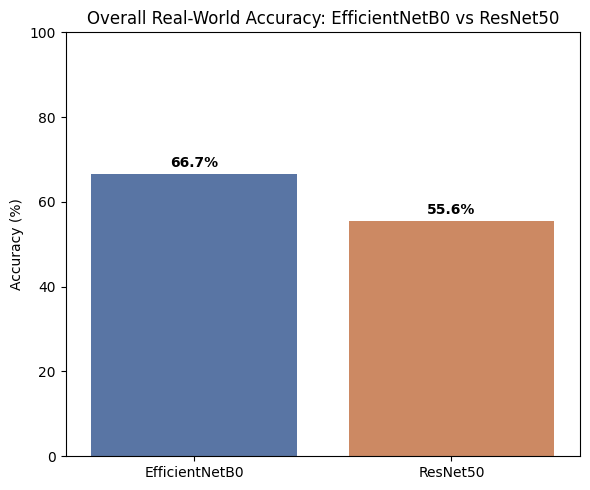

In [4]:
# Overall accuracy bar chart
plt.figure(figsize=(6, 5))
sns.barplot(x=names, y=accs, palette=["#4C72B0", "#DD8452"])
plt.ylabel("Accuracy (%)")
plt.title("Overall Real-World Accuracy: EfficientNetB0 vs ResNet50")
plt.ylim(0, 100)
for i, v in enumerate(accs):
        plt.text(i, v + 1.5, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "overall_accuracy_comparison.png"))
plt.show()

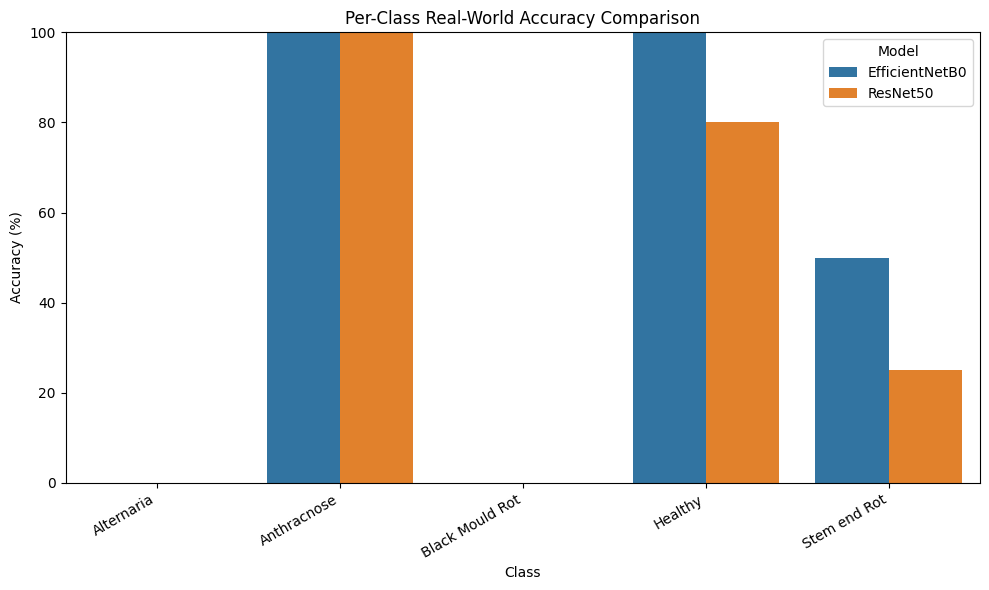

In [5]:
    # Per-class side-by-side bar chart
    merged = all_results[names[0]]["per_class"][["Class", "Accuracy (%)"]].rename(
        columns={"Accuracy (%)": names[0]})
    merged = merged.merge(
        all_results[names[1]]["per_class"][["Class", "Accuracy (%)"]].rename(
            columns={"Accuracy (%)": names[1]}),
        on="Class", how="outer")

    merged_melted = merged.melt(id_vars="Class", var_name="Model", value_name="Accuracy (%)")
    plt.figure(figsize=(10, 6))
    sns.barplot(data=merged_melted, x="Class", y="Accuracy (%)", hue="Model")
    plt.title("Per-Class Real-World Accuracy Comparison")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "per_class_accuracy_comparison.png"))
    plt.show()

In [8]:
winner = names[0] if accs[0] > accs[1] else names[1]
print(f"\nBased on real-world accuracy, {winner} performs better "
          f"({max(accs):.2f}% vs {min(accs):.2f}%).")
print("NOTE: with a small real-world test set, treat this as directional,")
print("not definitive - aim for at least ~15-20 images per class before")
print("fully trusting the gap between the two models.")

print(f"\nAll results saved to: {OUT_DIR}/")


Based on real-world accuracy, EfficientNetB0 performs better (66.67% vs 55.56%).
NOTE: with a small real-world test set, treat this as directional,
not definitive - aim for at least ~15-20 images per class before
fully trusting the gap between the two models.

All results saved to: fruit_google_test_results/
